In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# We use low_memory=False to handle large columns efficiently
df = pd.read_csv('1429_1.csv', low_memory=False)

# 2. Check the size of the data (Rows, Columns)
print(f"Dataset Shape: {df.shape}\n")

# 3. Check column names, data types, and non-null counts
print("--- Dataset Information ---")
df.info()

# 4. View the first 5 rows to see what the data actually looks like
df.head()

Dataset Shape: (34660, 21)

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34660 entries, 0 to 34659
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    34660 non-null  object 
 1   name                  27900 non-null  object 
 2   asins                 34658 non-null  object 
 3   brand                 34660 non-null  object 
 4   categories            34660 non-null  object 
 5   keys                  34660 non-null  object 
 6   manufacturer          34660 non-null  object 
 7   reviews.date          34621 non-null  object 
 8   reviews.dateAdded     24039 non-null  object 
 9   reviews.dateSeen      34660 non-null  object 
 10  reviews.didPurchase   1 non-null      object 
 11  reviews.doRecommend   34066 non-null  object 
 12  reviews.id            1 non-null      float64
 13  reviews.numHelpful    34131 non-null  float64
 14  reviews.rating

,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


In [2]:
# 1. Check for missing values in our key columns
print("Missing Ratings:", df['reviews.rating'].isnull().sum())
print("Missing Review Text:", df['reviews.text'].isnull().sum())

# 2. Drop rows where review text is missing so NLP doesn't break later
df = df.dropna(subset=['reviews.text'])

# 3. Get statistical breakdown of ratings
print("\nRating Statistics:")
print(df['reviews.rating'].describe())

Missing Ratings: 33
Missing Review Text: 1

Rating Statistics:
count    34626.000000
mean         4.584561
std          0.735660
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: reviews.rating, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_15716\3092357545.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='reviews.rating', palette='viridis')


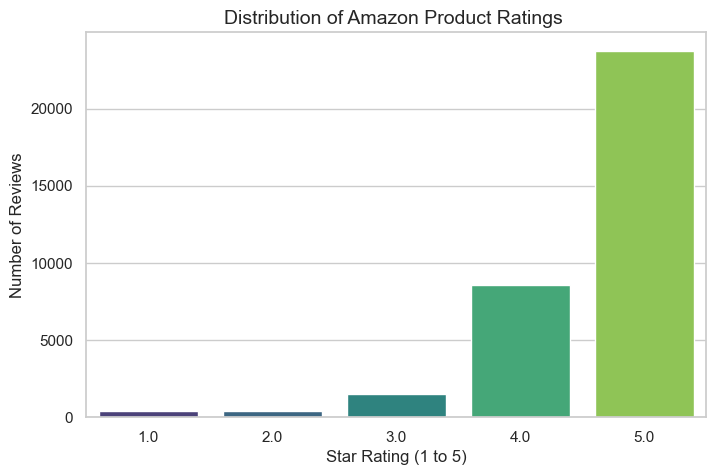

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for the plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Create a distribution count plot for ratings
sns.countplot(data=df, x='reviews.rating', palette='viridis')

# Add titles and labels
plt.title('Distribution of Amazon Product Ratings ', fontsize=14)
plt.xlabel('Star Rating (1 to 5)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

# Show the plot clearly
plt.show()

In [5]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# 1. Download the pre-trained VADER lexicon dataset
nltk.download('vader_lexicon')

# 2. Initialize the sentiment analyzer
sia = SentimentIntensityAnalyzer()

# 3. Create a quick helper function to extract the 'compound' sentiment score
def get_sentiment_score(text):
    return sia.polarity_scores(str(text))['compound']

# 4. Apply the sentiment analyzer to the entire review column 
print("Running NLP Sentiment Analysis... (this might take 10-20 seconds)")
df['sentiment_score'] = df['reviews.text'].apply(get_sentiment_score)

# 5. Create a function to group scores into Positive, Negative, and Neutral categories
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# Apply the category groupings to a new column
df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)
print("Analysis Complete!")

# View our text alongside the freshly calculated scores and categories
df[['reviews.text', 'sentiment_score', 'sentiment_category']].head(10)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...


Running NLP Sentiment Analysis... (this might take 10-20 seconds)
Analysis Complete!


,reviews.text,sentiment_score,sentiment_category
0,This product so far has not disappointed. My c...,0.9194,Positive
1,great for beginner or experienced person. Boug...,0.8934,Positive
2,Inexpensive tablet for him to use and learn on...,0.4404,Positive
3,I've had my Fire HD 8 two weeks now and I love...,0.9884,Positive
4,I bought this for my grand daughter when she c...,0.7876,Positive
5,This amazon fire 8 inch tablet is the perfect ...,0.7096,Positive
6,"Great for e-reading on the go, nice and light ...",0.8885,Positive
7,"I gave this as a Christmas gift to my inlaws, ...",0.9273,Positive
8,Great as a device to read books. I like that i...,0.7809,Positive
9,I love ordering books and reading them with th...,0.6369,Positive


C:\Users\User\AppData\Local\Temp\ipykernel_15716\2312180746.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment_category', order=['Positive', 'Neutral', 'Negative'], palette='Set2')


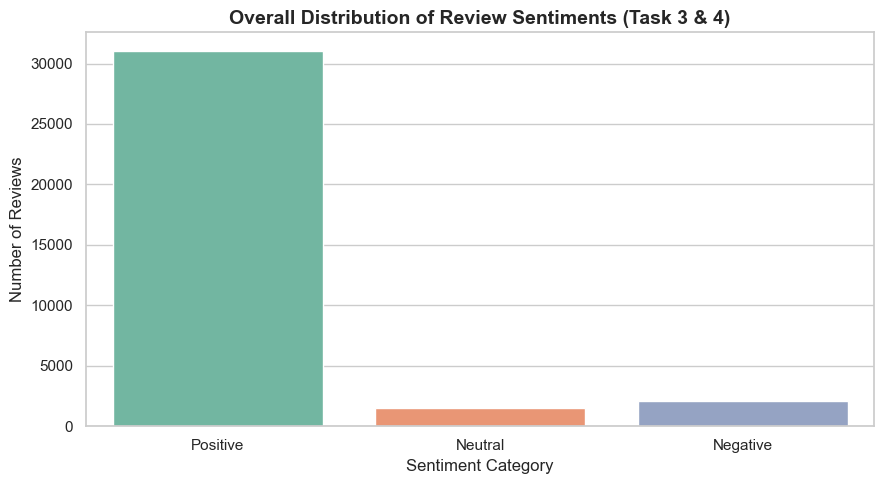

C:\Users\User\AppData\Local\Temp\ipykernel_15716\2312180746.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='reviews.rating', y='sentiment_score', palette='Blues')


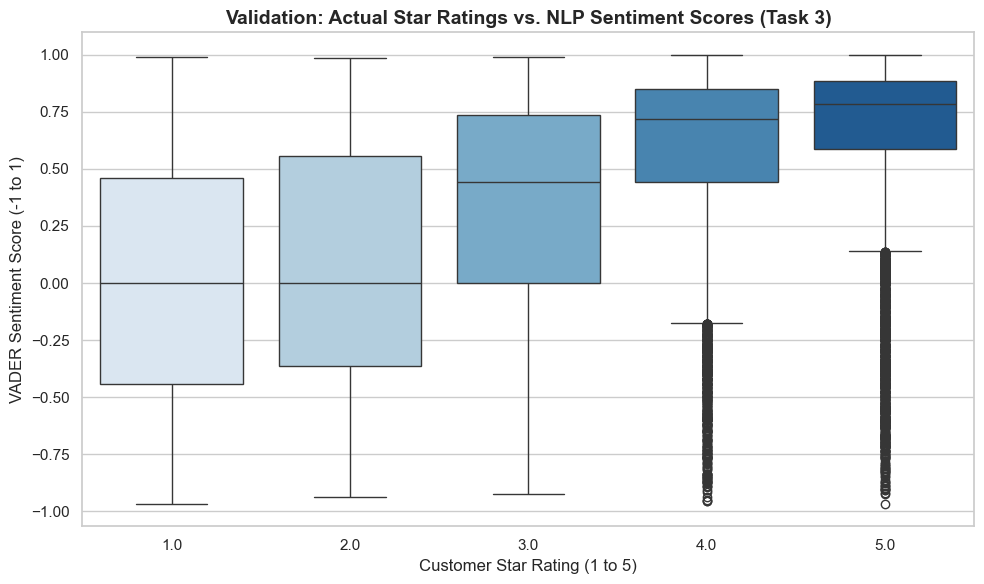

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional, clean style for the charts
sns.set_theme(style="whitegrid")

# Chart 1: Distribution of Sentiment Categories
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='sentiment_category', order=['Positive', 'Neutral', 'Negative'], palette='Set2')
plt.title('Overall Distribution of Review Sentiments (Task 3 & 4)', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.tight_layout()
plt.show()

# Chart 2: Comparing Actual Star Ratings to Calculated Sentiment Scores
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='reviews.rating', y='sentiment_score', palette='Blues')
plt.title('Validation: Actual Star Ratings vs. NLP Sentiment Scores (Task 3)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Star Rating (1 to 5)', fontsize=12)
plt.ylabel('VADER Sentiment Score (-1 to 1)', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# Save the updated dataset containing your new sentiment columns
df.to_csv('Amazon_Reviews_With_Sentiment.csv', index=False)
print("Success! Your Tableau-ready file is saved in your project directory.")

Success! Your Tableau-ready file is saved in your project directory.
